In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

import pickle

import schwingerModel as sim

In [ ]:
with open('configs/50kSteps.pkl', 'rb') as f:
    temp = pickle.load(f)

In [3]:
m = temp.fMass
a = temp.a
dimx = temp.dimx
dimt = temp.dimt
beta = temp.beta
totalSteps = temp.metroSteps

In [4]:
print(m)
print(a)
print(dimx)
print(dimt)
print(beta)
print(totalSteps)

0.2
1
16
32
10
50000


In [5]:
ti=1
def coshCorrel(nt, Energy):
    return (np.exp(-(nt+ti)*Energy)+np.exp(((nt+ti)-dimt)*Energy))/(np.exp(-(ti)*Energy)+np.exp(((ti)-dimt)*Energy))
def expDecay(nt, Energy):
    return np.exp(-nt*Energy)

In [16]:
bIn = 500
skp = 100

gamma = np.array([[1j,0],[0,-1j]])
correlSigma3 = sim.correlation.GEVPStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,smearNs=[0,2],kappas=[0,1.2],ti=ti,momk=0)
correlSigma3Orig = sim.analysis.correlStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma)

100%|██████████| 495/495 [00:26<00:00, 18.80it/s]


In [18]:
effectiveMassSigma3Orig = sim.analysis.effectiveMassProp(correlSigma3Orig,coshExpr=True)

In [25]:
correlSigma3[1][:,:,1].shape

(2, 31)

(1e-08, 1000.0)

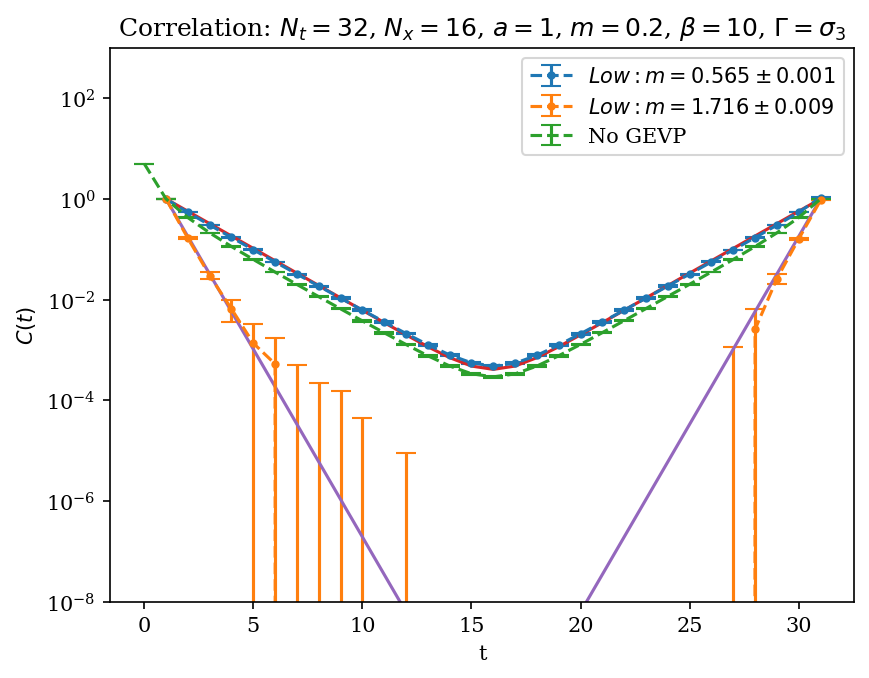

In [27]:
plt.figure(dpi=150)

masses = sim.correlation.gevpMassExtract(correlSigma3,fitT=[8,dimt-ti-8], ti=ti,eigenIdx=0)/a
mPS=masses[0]
dmPS = masses[1]

hiMass = sim.correlation.gevpMassExtract(correlSigma3,coshExpr=True,fitT=[1,dimt-ti],eigenIdx=1)/a

plt.errorbar(x=np.arange(ti,len(correlSigma3[0][:,0])+ti),y=correlSigma3[0][:,0],yerr=correlSigma3[1][:,:,0],ls="--",capsize=5,marker=".",label=rf"$Low: m={mPS:.3f}\pm{dmPS:.3f}$")
plt.errorbar(x=np.arange(ti,len(correlSigma3[0][:,1])+ti),y=correlSigma3[0][:,1],yerr=correlSigma3[1][:,:,1],ls="--",capsize=5,marker=".",label=rf"$Low: m={hiMass[0]:.3f}\pm{hiMass[1]:.3f}$")
plt.errorbar(x=np.arange(len(correlSigma3Orig[0])),y=correlSigma3Orig[0]/correlSigma3Orig[0][ti],yerr=correlSigma3Orig[1]/correlSigma3Orig[0][ti],ls="--",capsize=5,label=r"No GEVP")

# plt.plot(np.arange(ti,len(correlSigma3[0])+ti),np.exp(-mPS*np.arange(len(correlSigma3[0]))))
# plt.plot(np.arange(ti,len(correlSigma3[0])+ti),np.exp(-hiMass[0]*np.arange(len(correlSigma3[0]))))
plt.plot(np.arange(ti,len(correlSigma3[0])+ti),coshCorrel(np.arange(len(correlSigma3[0])),mPS*a))
plt.plot(np.arange(ti,len(correlSigma3[0])+ti),coshCorrel(np.arange(len(correlSigma3[0])),hiMass[0]*a))

plt.semilogy()
plt.xlabel("t")
plt.ylabel(r"$C(t)$")
plt.title(rf"Correlation: $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")
plt.legend()
plt.ylim([1e-8,1e3])

(0.0, 4.0)

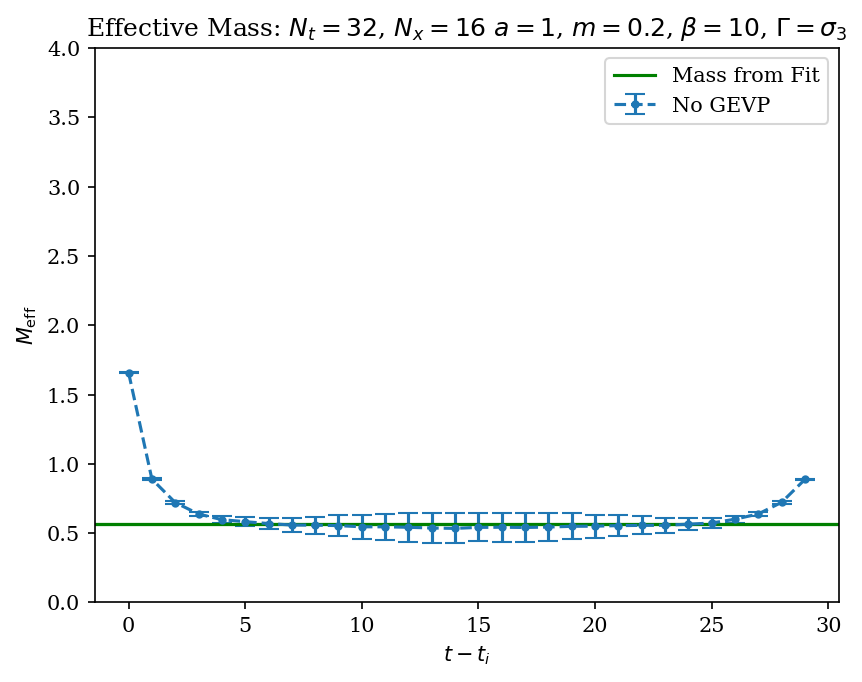

In [28]:
plt.figure(dpi=150)

# plt.errorbar(x=np.arange(len(effectiveMassSigma3[0])),y=(effectiveMassSigma3[0]),yerr=effectiveMassSigma3[1],ls="--",marker=".",capsize=5,label=r"GEVP")
plt.errorbar(x=np.arange(len(effectiveMassSigma3Orig[0])),y=(effectiveMassSigma3Orig[0]),yerr=effectiveMassSigma3Orig[1],ls="--",marker=".",capsize=5,label=r"No GEVP")

plt.axhline((mPS+dmPS)*a,color="green",label="Mass from Fit")
plt.axhline((mPS-dmPS)*a,color="green")

plt.xlabel(r"$t-t_i$")
plt.xlabel(r"$t-t_i$")
plt.ylabel(r"$M_{\text{eff}}$")
plt.title(rf"Effective Mass: $N_t = {dimt}$, $N_x={dimx}$ $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")
plt.legend()
plt.ylim([0,4])

In [41]:
ks = np.arange(3)
correls = []

for k in ks:
    correlSigma3 = sim.correlation.GEVPStats(temp, burnIn=bIn,autocorrSkip=skp,Gamma=gamma,smearN1=1,kappa1=1.2,ti=1,momk=k)
    correls.append(correlSigma3)

100%|██████████| 495/495 [00:10<00:00, 48.26it/s]


In [23]:
masses = []
for corr in correls:
    masses.append(sim.correlation.gevpMassExtract(corr,fitT=14))

np.array(masses)

array([[1.08231896, 0.00447654],
       [1.22315808, 0.0049969 ],
       [1.26000845, 0.00868182]])

Text(0.5, 1.0, 'Dispersion Relation: $N_t=16$, $N_x=8$, $a=2$, $m=0.2$, $\\beta=2.5$, $\\Gamma=\\sigma_3$')

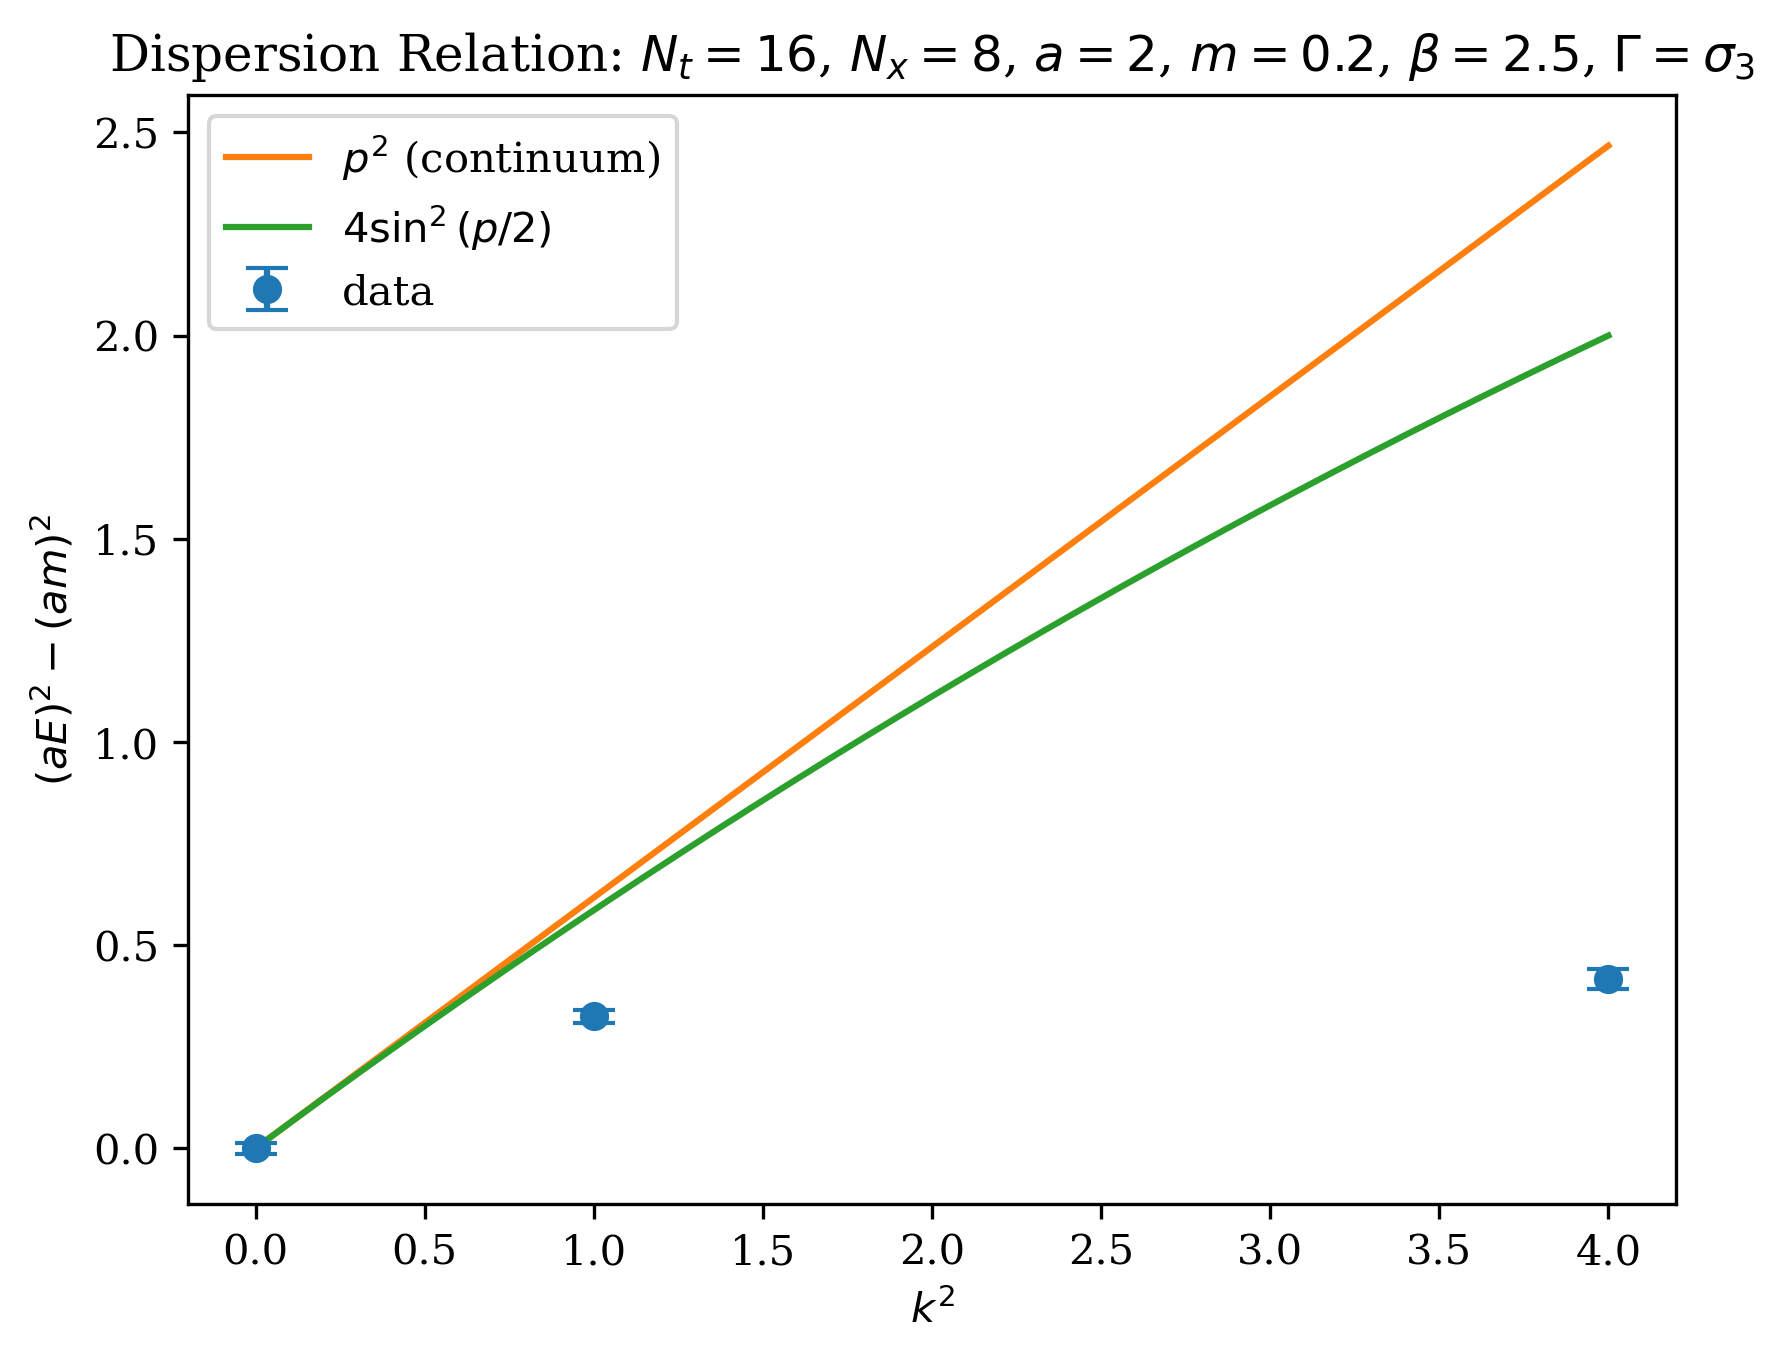

In [26]:
ps = (2*np.pi/dimx)*ks


masses = np.array(masses)
energyEstimates    = masses[:,0]
energyEstimatesErr = masses[:,1]

kineticDispersion = energyEstimates**2 - energyEstimates[0]**2
dispErr = 2*np.sqrt((energyEstimates*energyEstimatesErr)**2
                    + (energyEstimates[0]*energyEstimatesErr[0])**2)

# fine grid for smooth curves
k_fine = np.linspace(0, ks.max(), 400)
p_fine = (2*np.pi/dimx)*k_fine
m_phys = energyEstimates[0]

plt.figure(dpi=300)
plt.errorbar(ks**2, kineticDispersion, yerr=dispErr, capsize=5, ls="", marker="o", label="data")
plt.plot(k_fine**2, p_fine**2, label=r"$p^2$ (continuum)")
plt.plot(k_fine**2, 4*np.sin(p_fine/2)**2, label=r"$4\sin^2(p/2)$")
plt.xlabel("$k^2$")
plt.ylabel(r"$(aE)^2-(am)^2$")
plt.legend()
plt.title(rf"Dispersion Relation: $N_t={dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta}$, $\Gamma=\sigma_3$")